# 05 - Theme first derivative (catch the take-off)

Identical logic to notebook 03, but operating on **themes** instead of individual
tickers. Reads `data/processed/daily_theme_counts.parquet` (produced by notebook 04).

**The idea:** smooth the daily theme signal, then take the first derivative
(how much did it change since yesterday?). When that speed jumps well above normal,
a theme is catching fire in retail discussion. We mark those days in red.

Notebook 04 saves **two signals per theme** — pick which one to analyse with
`VALUE_COLUMN`:

- `keyword_count` — posts whose text mentions the theme's words/phrases
- `inferred_count` — ticker mentions mapped to the theme (NVDA → ai, ...)
- `keyword_weighted` / `inferred_weighted` — the upvote-weighted (score²) versions

In [31]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [32]:
# ============ PARAMETERS - edit these ============
DAILY_THEMES_PATH = os.path.join(ROOT, 'data', 'processed', 'daily_theme_counts.parquet')
VALUE_COLUMN      = 'keyword_count'   # 'keyword_count', 'inferred_count',
                                      # 'keyword_weighted' or 'inferred_weighted'
THEMES            = []     # e.g. ['ai', 'gold_metals']; [] = use the TOP_N most mentioned
TOP_N             = 4
SMOOTH            = 3      # rolling-average window in days
K                 = 2.0    # std-devs above normal that counts as a take-off
# ==================================================

In [33]:
# ============ TIME WINDOW - edit freely ============
# Clips the daily counts before the analysis. None = keep everything in the
# counts file (which was already windowed when notebook 02/04 produced it).
START_DATE = None   # inclusive,  'YYYY-MM-DD' or None
END_DATE   = None   # EXCLUSIVE,  'YYYY-MM-DD' or None
# ====================================================

In [34]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Force-reload src.inflection so an already-running kernel picks up edits
# to the module without a restart (same reasoning as notebook 03).
import importlib
import src.inflection
importlib.reload(src.inflection)
from src.inflection import build_daily_series, compute_inflection

def format_date_axis(ax, rotate=45):
    """Weekly (Monday) YYYY-MM-DD ticks - same axis style as notebook 03."""
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    for label in ax.get_xticklabels():
        label.set_rotation(rotate)
        label.set_ha('right')
        label.set_fontsize(7)
    ax.grid(True, which='major', axis='x', alpha=0.3)

daily = pd.read_parquet(DAILY_THEMES_PATH)
daily['date'] = pd.to_datetime(daily['date'])

# Apply the time window from the cell above.
if START_DATE:
    daily = daily[daily['date'] >= pd.Timestamp(START_DATE)]
if END_DATE:
    daily = daily[daily['date'] < pd.Timestamp(END_DATE)]
print('window:', START_DATE, 'to', END_DATE, '|', len(daily), 'daily rows kept')

# inflection.py expects a 'ticker' column; rename 'theme' so it works unchanged.
daily = daily.rename(columns={'theme': 'ticker'})

# Old theme files had mention_count; the new ones have the four signal
# columns. Fall back sensibly either way.
if VALUE_COLUMN not in daily.columns:
    fallback = 'keyword_count' if 'keyword_count' in daily.columns else 'mention_count'
    print('NOTE:', VALUE_COLUMN, 'not found - using', fallback, 'instead.')
    VALUE_COLUMN = fallback

if THEMES:
    chosen = THEMES
else:
    totals = daily.groupby('ticker')[VALUE_COLUMN].sum().sort_values(ascending=False)
    chosen = list(totals.head(TOP_N).index)
print('analysing:', chosen, '| signal:', VALUE_COLUMN)

window: None to None | 5440 daily rows kept
analysing: ['crypto', 'options_volatility', 'financials', 'ai_megacap'] | signal: keyword_count



crypto (keyword_count): 12 rise day(s), 7 fall day(s), 1 peak(s), 1 trough(s)
    RISE   2024-01-26 | value 22 | velocity 4.7
    RISE   2024-02-27 | value 32 | velocity 5.0
    RISE   2024-02-28 | value 46 | velocity 11.7
    RISE   2024-02-29 | value 34 | velocity 4.7
    RISE   2024-03-04 | value 48 | velocity 5.7
    RISE   2024-03-05 | value 54 | velocity 8.7
    RISE   2024-03-13 | value 39 | velocity 4.7
    RISE   2024-04-06 | value 28 | velocity 5.3
    RISE   2024-04-19 | value 27 | velocity 5.0
    RISE   2024-11-06 | value 23 | velocity 5.0
    RISE   2024-11-12 | value 26 | velocity 4.7
    RISE   2024-12-05 | value 31 | velocity 7.3
    FALL   2024-01-14 | value 9 | velocity -5.3
    FALL   2024-03-02 | value 28 | velocity -6.0
    FALL   2024-03-07 | value 28 | velocity -6.7
    FALL   2024-03-08 | value 32 | velocity -7.3
    FALL   2024-05-30 | value 5 | velocity -4.7
    FALL   2024-09-08 | value 3 | velocity -4.7
    FALL   2024-11-17 | value 11 | velocity -5.3
    

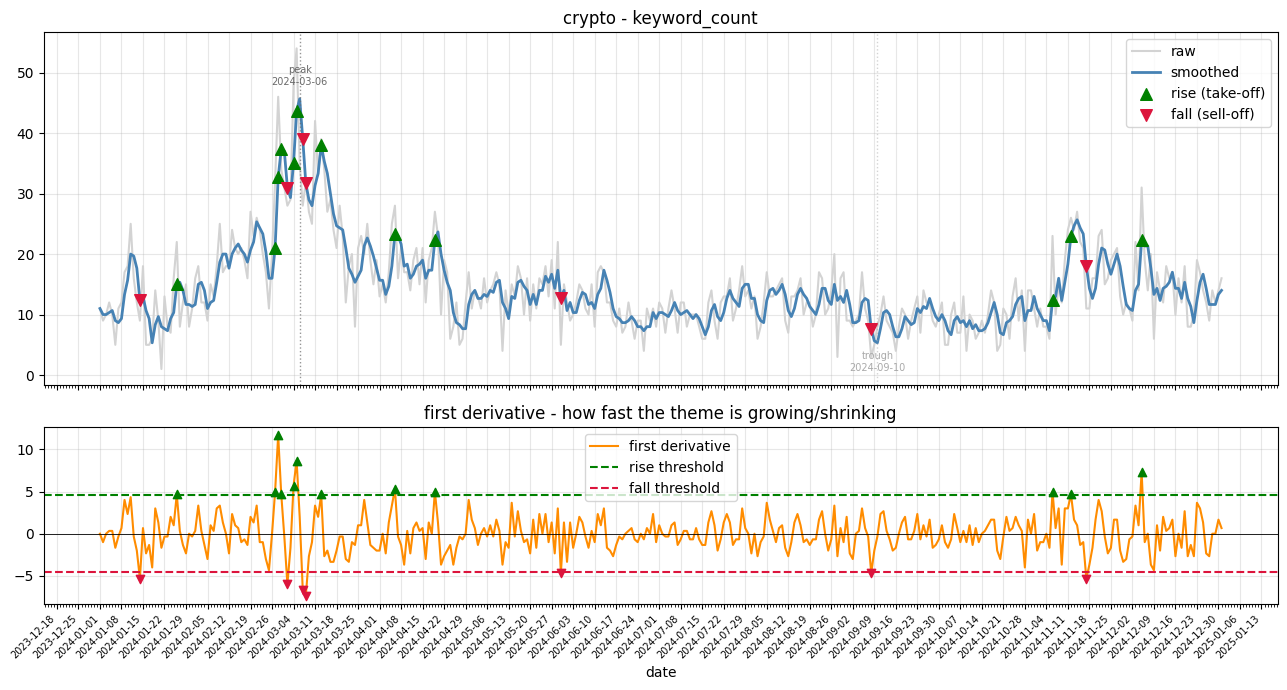


options_volatility (keyword_count): 7 rise day(s), 8 fall day(s), 6 peak(s), 6 trough(s)
    RISE   2024-01-29 | value 15 | velocity 3.7
    RISE   2024-03-19 | value 15 | velocity 3.3
    RISE   2024-04-16 | value 11 | velocity 2.7
    RISE   2024-05-24 | value 17 | velocity 5.0
    RISE   2024-07-30 | value 11 | velocity 2.7
    RISE   2024-08-16 | value 13 | velocity 3.3
    RISE   2024-09-18 | value 12 | velocity 3.0
    FALL   2024-03-17 | value 5 | velocity -3.7
    FALL   2024-04-12 | value 2 | velocity -3.0
    FALL   2024-05-27 | value 2 | velocity -5.0
    FALL   2024-08-11 | value 5 | velocity -2.7
    FALL   2024-08-19 | value 5 | velocity -2.7
    FALL   2024-08-25 | value 2 | velocity -3.0
    FALL   2024-09-21 | value 1 | velocity -3.7
    FALL   2024-10-28 | value 0 | velocity -2.7
    PEAK   2024-03-15
    PEAK   2024-03-21
    PEAK   2024-05-25
    PEAK   2024-06-22
    PEAK   2024-08-16
    PEAK   2024-10-17
    TROUGH 2024-03-18
    TROUGH 2024-05-22
    TROUGH 202

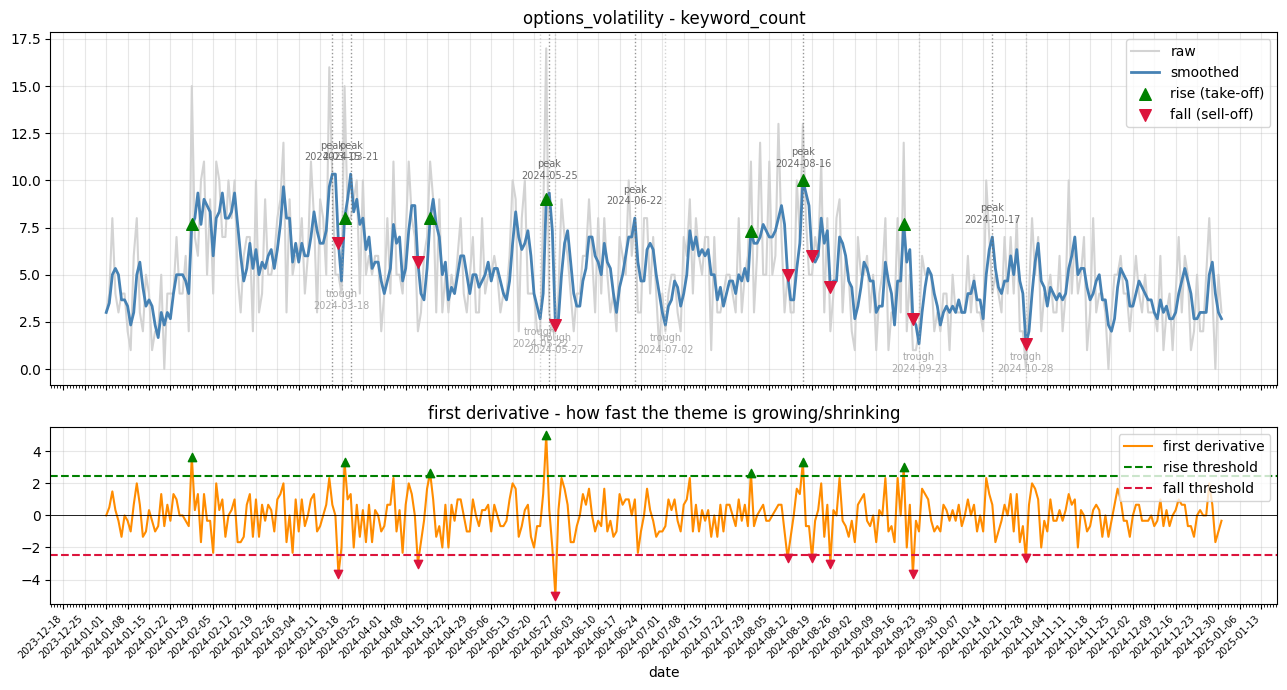


financials (keyword_count): 12 rise day(s), 11 fall day(s), 6 peak(s), 6 trough(s)
    RISE   2024-01-27 | value 7 | velocity 2.3
    RISE   2024-02-02 | value 15 | velocity 3.0
    RISE   2024-02-22 | value 10 | velocity 2.7
    RISE   2024-03-05 | value 8 | velocity 2.3
    RISE   2024-04-03 | value 13 | velocity 3.0
    RISE   2024-05-11 | value 9 | velocity 2.3
    RISE   2024-05-29 | value 13 | velocity 3.0
    RISE   2024-06-07 | value 11 | velocity 3.0
    RISE   2024-06-23 | value 12 | velocity 2.3
    RISE   2024-08-16 | value 9 | velocity 2.3
    RISE   2024-08-29 | value 7 | velocity 2.3
    RISE   2024-12-31 | value 8 | velocity 2.7
    FALL   2024-02-05 | value 2 | velocity -4.3
    FALL   2024-02-10 | value 4 | velocity -3.0
    FALL   2024-02-25 | value 2 | velocity -2.7
    FALL   2024-04-06 | value 3 | velocity -3.3
    FALL   2024-04-25 | value 2 | velocity -2.7
    FALL   2024-06-01 | value 4 | velocity -3.0
    FALL   2024-06-26 | value 2 | velocity -3.3
    FALL  

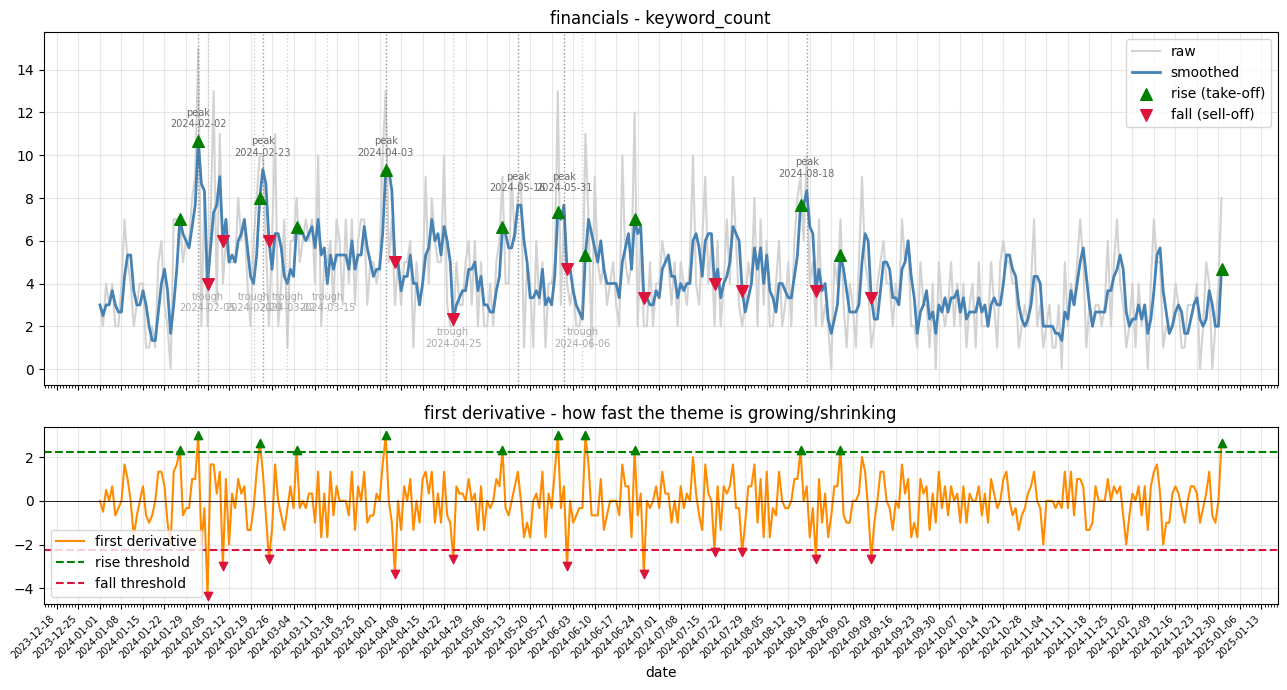


ai_megacap (keyword_count): 10 rise day(s), 9 fall day(s), 5 peak(s), 7 trough(s)
    RISE   2024-01-25 | value 9 | velocity 2.3
    RISE   2024-01-31 | value 6 | velocity 2.0
    RISE   2024-02-21 | value 11 | velocity 3.3
    RISE   2024-02-27 | value 10 | velocity 2.7
    RISE   2024-04-16 | value 6 | velocity 2.0
    RISE   2024-04-25 | value 10 | velocity 2.3
    RISE   2024-04-30 | value 7 | velocity 2.0
    RISE   2024-05-23 | value 7 | velocity 2.0
    RISE   2024-10-24 | value 6 | velocity 2.0
    RISE   2024-12-12 | value 6 | velocity 2.0
    FALL   2024-01-28 | value 0 | velocity -3.0
    FALL   2024-02-24 | value 2 | velocity -3.0
    FALL   2024-04-28 | value 1 | velocity -3.0
    FALL   2024-05-25 | value 3 | velocity -2.7
    FALL   2024-05-27 | value 2 | velocity -2.0
    FALL   2024-06-16 | value 2 | velocity -2.3
    FALL   2024-07-14 | value 2 | velocity -2.3
    FALL   2024-08-31 | value 0 | velocity -3.7
    FALL   2024-09-01 | value 0 | velocity -2.0
    PEAK   2

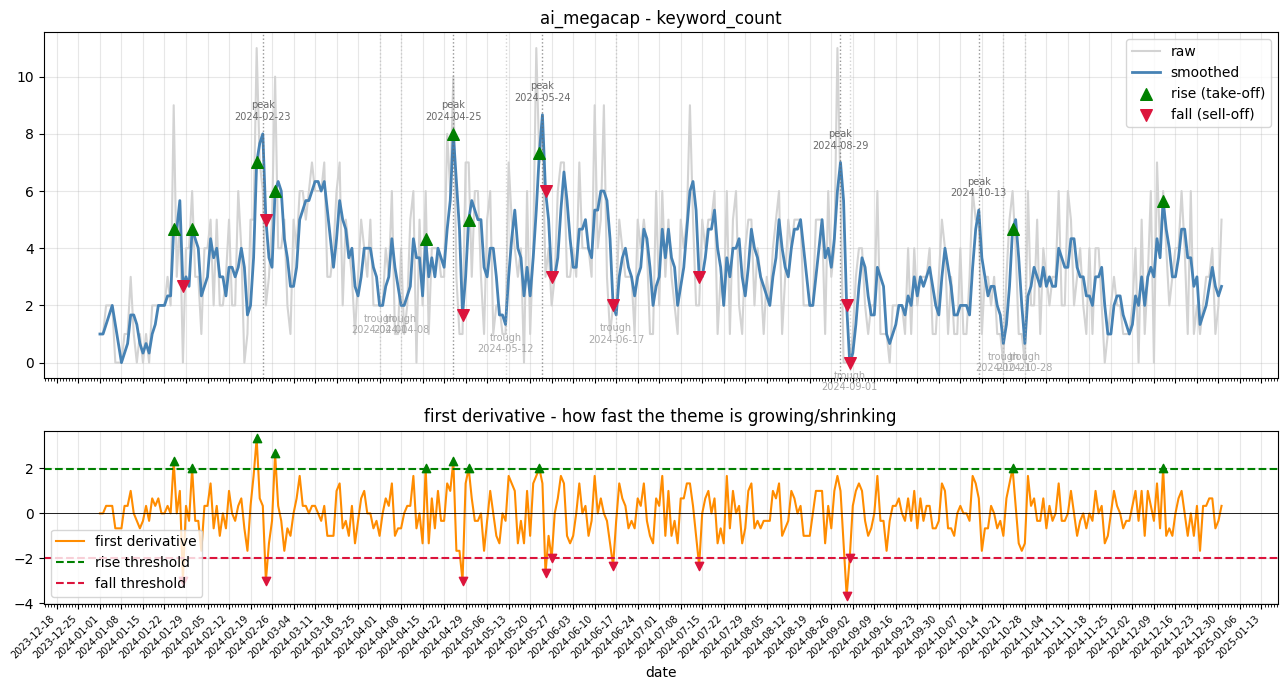

In [35]:
for theme in chosen:
    series = build_daily_series(daily, theme, value_col=VALUE_COLUMN)
    if series is None:
        print('skip', theme, '(not found)'); continue
    result = compute_inflection(series, SMOOTH, K)
    rises = result[result['is_rise']]
    falls = result[result['is_fall']]
    peaks = result[result['is_peak']]
    troughs = result[result['is_trough']]

    print(f'\n{theme} ({VALUE_COLUMN}): {len(rises)} rise day(s), {len(falls)} fall day(s), '
          f'{len(peaks)} peak(s), {len(troughs)} trough(s)')
    for date, row in rises.iterrows():
        print('    RISE  ', date.strftime('%Y-%m-%d'), '| value', int(row['count']), '| velocity', round(row['velocity'], 1))
    for date, row in falls.iterrows():
        print('    FALL  ', date.strftime('%Y-%m-%d'), '| value', int(row['count']), '| velocity', round(row['velocity'], 1))
    for date in peaks.index:
        print('    PEAK  ', date.strftime('%Y-%m-%d'))
    for date in troughs.index:
        print('    TROUGH', date.strftime('%Y-%m-%d'))

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    top.plot(result.index, result['count'], color='lightgray', label='raw')
    top.plot(result.index, result['smoothed'], color='steelblue', linewidth=2, label='smoothed')
    top.scatter(rises.index, rises['smoothed'], color='green', marker='^', s=70, zorder=5, label='rise (take-off)')
    top.scatter(falls.index, falls['smoothed'], color='crimson', marker='v', s=70, zorder=5, label='fall (sell-off)')
    # Peaks/troughs = where the trend itself turns; each label carries its
    # EXACT date so no squinting at the axis.
    for date in peaks.index:
        top.axvline(date, color='dimgray', linestyle=':', linewidth=1, alpha=0.7)
        top.annotate(f"peak\n{date:%Y-%m-%d}", (date, result.loc[date, 'smoothed']),
                     textcoords='offset points', xytext=(0, 10), ha='center',
                     fontsize=7, color='dimgray')
    for date in troughs.index:
        top.axvline(date, color='darkgray', linestyle=':', linewidth=1, alpha=0.5)
        top.annotate(f"trough\n{date:%Y-%m-%d}", (date, result.loc[date, 'smoothed']),
                     textcoords='offset points', xytext=(0, -20), ha='center',
                     fontsize=7, color='darkgray')
    top.set_title(f'{theme} - {VALUE_COLUMN}')
    top.legend(); top.grid(True, alpha=0.3)
    top.tick_params(labelbottom=False)   # dates appear once, on the shared axis below

    bottom.plot(result.index, result['velocity'], color='darkorange', label='first derivative')
    bottom.axhline(result.attrs['threshold'], color='green', linestyle='--', label='rise threshold')
    bottom.axhline(result.attrs['fall_threshold'], color='crimson', linestyle='--', label='fall threshold')
    bottom.axhline(0, color='black', linewidth=0.6)
    bottom.scatter(rises.index, rises['velocity'], color='green', marker='^', zorder=5)
    bottom.scatter(falls.index, falls['velocity'], color='crimson', marker='v', zorder=5)
    bottom.set_title('first derivative - how fast the theme is growing/shrinking')
    bottom.set_xlabel('date')
    bottom.legend(); bottom.grid(True, alpha=0.3)
    format_date_axis(bottom)   # weekly YYYY-MM-DD ticks, same as notebook 03
    plt.tight_layout(); plt.show()